# Assessment 2 — Python Notebook 

Section A:

    A1. Imports  
    A2. Load raw dataset  
    A3. Initial data understanding  
    A4. Data cleaning and standardisation  
    A5. Convert numeric columns
    A6. Repare Month and Month_name
    A7. Remove Duplicates
    A8. Handle Missing Values
    A9. Create Date Column
    A10. Feature engineering  
    A11. Final data types and category ordering
    A12. Validation checks  

Section B:

    B1. Descriptive analytics
        B1.1. Summary tables required by the assessment
        B1.2. Monthly trend lines
        B1.3. Heatmap: Day_of_week vs Mode
        B1.4. Bar chart with 95% CI error bars
        B1.5. Distribution checks and normality
        B1.6. Histogram and KDE and Q-Q plot
    B2. Modelling
        B2.1. Segmented comparison across Period with 95% CIs
        B2.2. Plain-language interpretation for modelling
    B3. Probability statement
        B3.1. Estimate probability of exceeding a threshold on Normal Weekdays
        B3.2. Plain-language probability interpretation


Section C:

    C1. Two-sample t-test for chosen_mode with Weekday vs Weekend comparison (per Mode)
    C2. One-way ANOVA with Differences across Modes on Normal Weekdays
    C3. Pre vs Post comparison (chosen Mode and Day_type)

Section D:

    D1. Save cleaned data and summary outputs for Final Report

# Section A:
## A1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, levene
from IPython.display import display



pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 60) 


## A2. Load raw dataset

In [2]:
FILE_NAME = "../data/Dataset- Monthly average patronage by day type and by mode.csv"

df_raw = pd.read_csv(FILE_NAME)
df = df_raw.copy()

print("Initial shape:", df.shape)
display(df.head())

Initial shape: (4300, 7)


,Year,Month,Month_name,Day_of_week,Day_type,Mode,Pax_daily
0,2018,1,Jan,Friday,School Holiday Weekday,MetroBus,268350
1,2018,1,Jan,Friday,School Holiday Weekday,MetroTrain,570700
2,2018,1,Jan,Friday,School Holiday Weekday,RegionalBus,21550
3,2018,1,Jan,Friday,School Holiday Weekday,RegionalTrain,43700
4,2018,1,Jan,Friday,School Holiday Weekday,Tram,529250


## A3. Initial data understanding

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types before cleaning:")
display(df.dtypes)

print("\nMissing values before cleaning:")
missing_before = df.isna().sum()
display(missing_before.to_frame("Missing Before"))

duplicates_before = df.duplicated().sum()
print("Duplicate rows before cleaning:", duplicates_before)

for col in ["Mode", "Day_type", "Day_of_week", "Month_name"]:
    print(f"\nUnique values in {col}:")
    print(sorted(df[col].astype(str).unique())[:20])
    
print("\nBasic statistical summary:")
display(df.describe())

Columns:
['Year', 'Month', 'Month_name', 'Day_of_week', 'Day_type', 'Mode', 'Pax_daily']

Data types before cleaning:


Year            int64
Month           int64
Month_name     object
Day_of_week    object
Day_type       object
Mode           object
Pax_daily       int64
dtype: object


Missing values before cleaning:


,Missing Before
Year,0
Month,0
Month_name,0
Day_of_week,0
Day_type,0
Mode,0
Pax_daily,0


Duplicate rows before cleaning: 0

Unique values in Mode:
['MetroBus', 'MetroTrain', 'RegionalBus', 'RegionalTrain', 'Tram']

Unique values in Day_type:
['Normal Weekday', 'School Holiday Weekday', 'Weekend']

Unique values in Day_of_week:
['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']

Unique values in Month_name:
['Apr', 'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar', 'May', 'Nov', 'Oct', 'Sep']

Basic statistical summary:


,Year,Month,Pax_daily
count,4300.000000,4300.000000,4300.000000
mean,2021.439535,6.551163,240732.313953
std,2.266255,3.383104,226797.336852
min,2018.000000,1.000000,1900.000000
25%,2019.000000,4.000000,37800.000000
50%,2021.000000,7.000000,165375.000000
75%,2023.000000,9.000000,406562.500000
max,2025.000000,12.000000,927650.000000


## A4. Data Cleaning and Standardisation

In [4]:
text_cols = ["Mode", "Day_type", "Day_of_week", "Month_name"]

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .replace({"Nan": np.nan, "nan": np.nan, "None": np.nan, "": np.nan})
    )

# Controlled standardisation

df["Day_of_week"] = df["Day_of_week"].str.capitalize()
df["Day_type"] = df["Day_type"].str.title()
df["Month_name"] = df["Month_name"].str.title()
df["Mode"] = df["Mode"].str.strip()

print("Text cleaning complete.")

Text cleaning complete.


## A5. Convert numeric columns

In [5]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Pax_daily"] = pd.to_numeric(df["Pax_daily"], errors="coerce")

#Enforce correct types 
df["Year"] = df["Year"].astype("Int64")
df["Month"] = df["Month"].astype("Int64")

print(df[["Year", "Month", "Pax_daily"]].dtypes)

Year         Int64
Month        Int64
Pax_daily    int64
dtype: object


## A6. Repair Month and Month_name 

In [6]:
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}
reverse_month_map = {v: k for k, v in month_map.items()}

df["Month"] = df["Month"].fillna(df["Month_name"].map(reverse_month_map))
df["Month_name"] = df["Month_name"].fillna(df["Month"].map(month_map))

# Re-enforce Month as integer-compatible type
df["Month"] = df["Month"].astype("Int64")

## A7. Remove duplicates

In [7]:
rows_before = len(df)
df = df.drop_duplicates().copy()
rows_after = len(df)

print("Duplicates removed:", rows_before - rows_after)
print("Shape after duplicate removal:", df.shape)

Duplicates removed: 0
Shape after duplicate removal: (4300, 7)


## A8. Handle missing values

In [8]:
critical_cols = ["Year", "Month", "Mode", "Day_type", "Day_of_week", "Pax_daily"]

print("Missing values before handling critical fields:")
display(df[critical_cols].isna().sum().to_frame("Missing Before"))

# Impute Pax_daily only if missing values exist
if df["Pax_daily"].isna().sum() > 0:
    df["Pax_daily"] = (
        df.groupby(["Mode", "Day_type"])["Pax_daily"]
        .transform(lambda x: x.fillna(x.median()))
    )

# Drop rows still missing critical fields
df = df.dropna(subset=critical_cols).copy()

print("Missing values after handling critical fields:")
display(df[critical_cols].isna().sum().to_frame("Missing After"))

Missing values before handling critical fields:


,Missing Before
Year,0
Month,0
Mode,0
Day_type,0
Day_of_week,0
Pax_daily,0


Missing values after handling critical fields:


,Missing After
Year,0
Month,0
Mode,0
Day_type,0
Day_of_week,0
Pax_daily,0


## A9. Create date column

In [9]:
df["Year"] = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)

df["MonthStart"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01",
    errors="coerce"
)

print("Null MonthStart values:", df["MonthStart"].isna().sum())
print("MonthStart dtype:", df["MonthStart"].dtype)
display(df[["Year", "Month", "MonthStart"]].head())

Null MonthStart values: 0
MonthStart dtype: datetime64[ns]


,Year,Month,MonthStart
0,2018,1,2018-01-01
1,2018,1,2018-01-01
2,2018,1,2018-01-01
3,2018,1,2018-01-01
4,2018,1,2018-01-01


## A10. Feature engineering

In [10]:
df["Period"] = np.where(
    df["Year"] < 2020, "Pre-2020",
    np.where(df["Year"] <= 2021, "2020-2021", "Post-2021")
)

weekday_list = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekend_list = ["Saturday", "Sunday"]

df["Is_Weekday"] = df["Day_of_week"].isin(weekday_list)

df["WeekPart"] = np.where(
    df["Day_of_week"].isin(weekday_list), "Weekday",
    np.where(df["Day_of_week"].isin(weekend_list), "Weekend", np.nan)
)

monthly_roll = (
    df.groupby(["Mode", "Day_type", "MonthStart"], as_index=False)["Pax_daily"]
      .mean()
      .sort_values(["Mode", "Day_type", "MonthStart"])
)

monthly_roll["Rolling_3M"] = (
    monthly_roll.groupby(["Mode", "Day_type"])["Pax_daily"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

df = df.merge(
    monthly_roll[["Mode", "Day_type", "MonthStart", "Rolling_3M"]],
    on=["Mode", "Day_type", "MonthStart"],
    how="left"
)
print("Null Rolling_3M values:", df["Rolling_3M"].isna().sum())
display(df[["Mode", "Day_type", "MonthStart", "Pax_daily", "Rolling_3M"]].head())

Null Rolling_3M values: 0


,Mode,Day_type,MonthStart,Pax_daily,Rolling_3M
0,MetroBus,School Holiday Weekday,2018-01-01,268350,292080.0
1,MetroTrain,School Holiday Weekday,2018-01-01,570700,614530.0
2,RegionalBus,School Holiday Weekday,2018-01-01,21550,23360.0
3,RegionalTrain,School Holiday Weekday,2018-01-01,43700,47520.0
4,Tram,School Holiday Weekday,2018-01-01,529250,556670.0


## A11. Final data types and category ordering

In [11]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
period_order = ["Pre-2020", "2020-2021", "Post-2021"]

df["Mode"] = df["Mode"].astype("category")
df["Day_type"] = df["Day_type"].astype("category")
df["Day_of_week"] = pd.Categorical(df["Day_of_week"], categories=day_order, ordered=True)
df["Period"] = pd.Categorical(df["Period"], categories=period_order, ordered=True)
df["WeekPart"] = df["WeekPart"].astype("category")
df["Month_name"] = df["Month_name"].astype("category")

df = df.reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Year         4300 non-null   int64         
 1   Month        4300 non-null   int64         
 2   Month_name   4300 non-null   category      
 3   Day_of_week  4300 non-null   category      
 4   Day_type     4300 non-null   category      
 5   Mode         4300 non-null   category      
 6   Pax_daily    4300 non-null   int64         
 7   MonthStart   4300 non-null   datetime64[ns]
 8   Period       4300 non-null   category      
 9   Is_Weekday   4300 non-null   bool          
 10  WeekPart     4300 non-null   category      
 11  Rolling_3M   4300 non-null   float64       
dtypes: bool(1), category(6), datetime64[ns](1), float64(1), int64(3)
memory usage: 198.8 KB


## A12. Validation checks

In [12]:
negative_pax = (df["Pax_daily"] < 0).sum()
z_scores = ((df["Pax_daily"] - df["Pax_daily"].mean()) / df["Pax_daily"].std()).abs()
outliers_z3 = (z_scores > 3).sum()

print("Negative Pax values:", negative_pax)
print("Outliers (z > 3):", outliers_z3)
print("Final shape:", df.shape)

# Optional interpretation note for outliers
if outliers_z3 > 0:
    print("Note: Outliers were identified using z-scores, but retained unless clearly invalid, as high patronage values may be genuine observations.")

missing_after = df.isna().sum()

comparison = pd.DataFrame({
    "Missing Before": missing_before,
    "Missing After": missing_after.reindex(missing_before.index, fill_value=0)
})
comparison["Fixed"] = comparison["Missing Before"] - comparison["Missing After"]

print("\nCleaning impact:")
display(comparison)

Negative Pax values: 0
Outliers (z > 3): 1
Final shape: (4300, 12)
Note: Outliers were identified using z-scores, but retained unless clearly invalid, as high patronage values may be genuine observations.

Cleaning impact:


,Missing Before,Missing After,Fixed
Year,0,0,0
Month,0,0,0
Month_name,0,0,0
Day_of_week,0,0,0
Day_type,0,0,0
Mode,0,0,0
Pax_daily,0,0,0


# Section B:
# B1. Descriptive analytics

## B1.1. Summary tables required by the assessment
   

In [13]:
desc_mode = df.groupby("Mode", observed=False)["Pax_daily"].agg(["mean", "median", "count"]).round(2)
desc_day_type = df.groupby("Day_type", observed=False)["Pax_daily"].agg(["mean", "median", "count"]).round(2)
desc_day_of_week = df.groupby("Day_of_week", observed=False)["Pax_daily"].agg(["mean", "median", "count"]).round(2)
desc_period = df.groupby("Period", observed=False)["Pax_daily"].agg(["mean", "median", "count"]).round(2)

print("DESCRIPTIVE STATS - MODE")
display(desc_mode)

print("DESCRIPTIVE STATS - DAY TYPE")
display(desc_day_type)

print("DESCRIPTIVE STATS - DAY OF WEEK")
display(desc_day_of_week)

print("DESCRIPTIVE STATS - PERIOD")
display(desc_period)

DESCRIPTIVE STATS - MODE


,mean,median,count
Mode,,,
MetroBus,281974.71,305975.0,860
MetroTrain,458138.14,458400.0,860
RegionalBus,27079.30,28950.0,860
RegionalTrain,39932.85,41100.0,860
Tram,396536.57,416325.0,860


DESCRIPTIVE STATS - DAY TYPE


,mean,median,count
Day_type,,,
Normal Weekday,281347.20,260050.0,2265
School Holiday Weekday,238330.97,195150.0,1085
Weekend,146640.47,122975.0,950


DESCRIPTIVE STATS - DAY OF WEEK


,mean,median,count
Day_of_week,,,
Monday,248087.07,210700.0,665
Tuesday,270939.18,223250.0,670
Wednesday,277055.22,240200.0,680
Thursday,276469.04,241150.0,680
Friday,264025.73,232100.0,655
Saturday,169497.79,152900.0,475
Sunday,123783.16,115300.0,475


DESCRIPTIVE STATS - PERIOD


,mean,median,count
Period,,,
Pre-2020,335312.69,331025.0,1080
2020-2021,127440.31,72700.0,1120
Post-2021,252513.38,272625.0,2100


## B1.2. Monthly trend lines


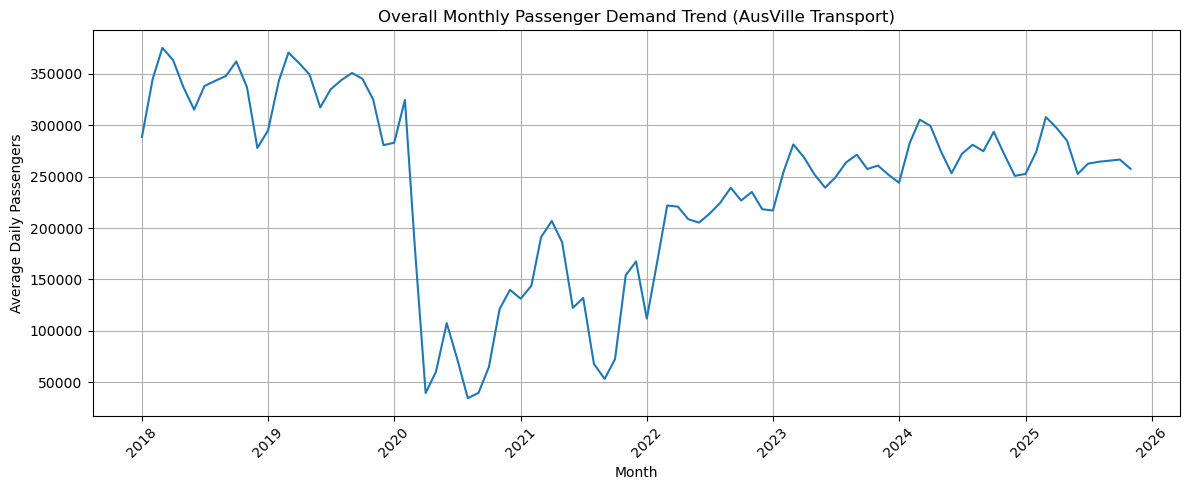

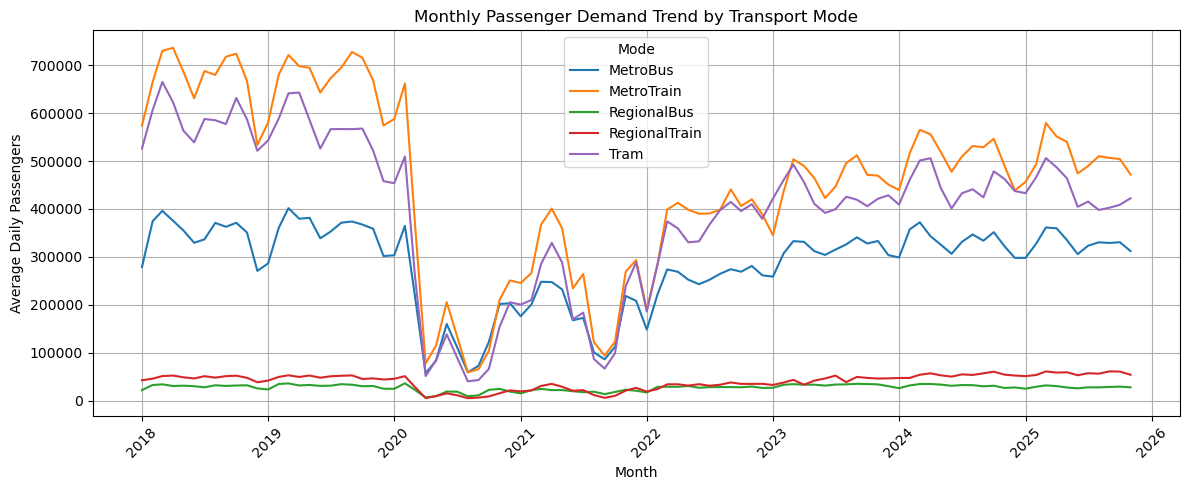

In [14]:
monthly_overall = (
    df.groupby("MonthStart", as_index=False, observed=False)["Pax_daily"]
    .mean()
    .sort_values("MonthStart")
)

monthly_by_mode = (
    df.groupby(["MonthStart", "Mode"], as_index=False, observed=False)["Pax_daily"]
    .mean()
    .sort_values("MonthStart")
)

# Overall trend
plt.figure(figsize=(12, 5))

plt.plot(monthly_overall["MonthStart"], monthly_overall["Pax_daily"])

plt.title("Overall Monthly Passenger Demand Trend (AusVille Transport)")
plt.xlabel("Month")
plt.ylabel("Average Daily Passengers")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

# Trend by Mode
plt.figure(figsize=(12, 5))

for mode, group in monthly_by_mode.groupby("Mode", observed=False):
    plt.plot(group["MonthStart"], group["Pax_daily"], label=mode)

plt.title("Monthly Passenger Demand Trend by Transport Mode")
plt.xlabel("Month")
plt.ylabel("Average Daily Passengers")
plt.xticks(rotation=45)
plt.legend(title="Mode")
plt.grid(True)

plt.tight_layout()
plt.show()

## B1.3. Heatmap: Day_of_week vs Mode


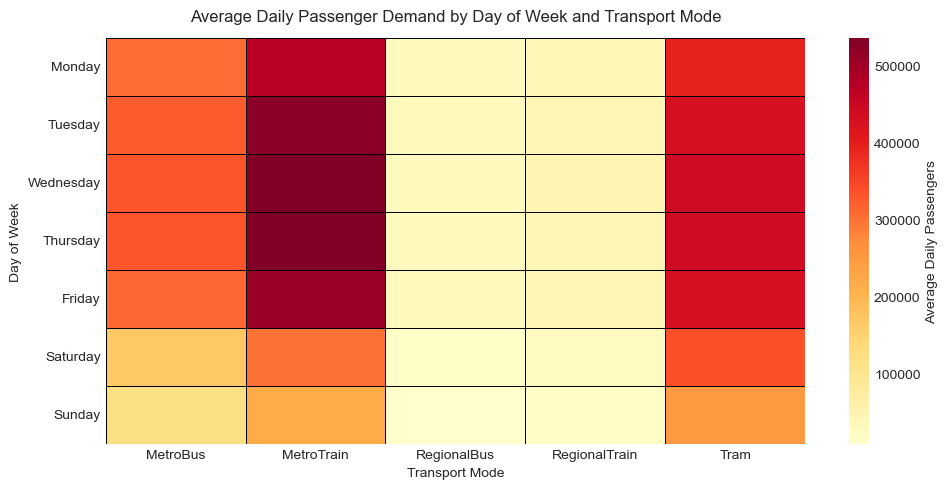

In [15]:
heat_map_table = (
    df.groupby(['Day_of_week','Mode'], observed=False)['Pax_daily']
      .mean()
      .unstack()
)

# Ensure correct order
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heat_map_table = heat_map_table.reindex(day_order)

plt.style.use('seaborn-v0_8-white')

plt.figure(figsize=(10, 5))

sns.heatmap(
    heat_map_table,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='black',
    cbar_kws={'label': 'Average Daily Passengers'}
)

plt.title('Average Daily Passenger Demand by Day of Week and Transport Mode', pad=12)
plt.xlabel('Transport Mode')
plt.ylabel('Day of Week')

plt.tight_layout()
plt.show()

## B1.4. Bar chart with 95% CI error bars
 

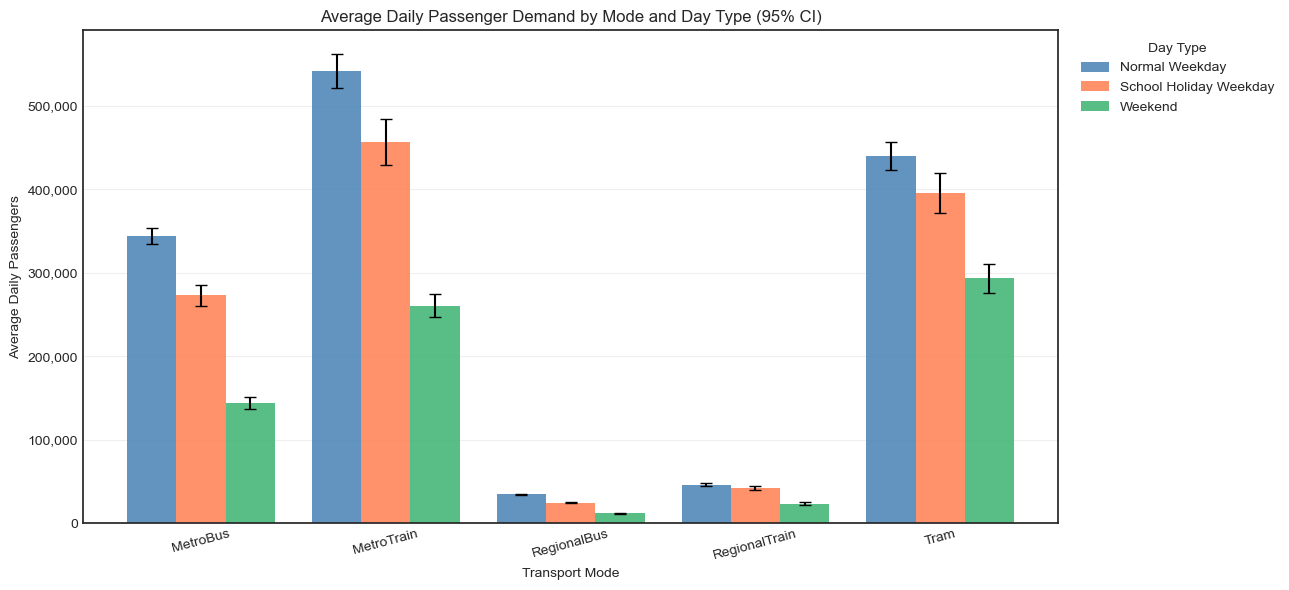

,Mode,Day_type,mean,ci
0,MetroBus,Normal Weekday,344031.24,9867.73
1,MetroBus,School Holiday Weekday,273054.61,12373.52
2,MetroBus,Weekend,144206.58,6824.80
3,MetroTrain,Normal Weekday,541870.97,20345.19
4,MetroTrain,School Holiday Weekday,456617.05,27406.46
5,MetroTrain,Weekend,260238.68,13715.87
6,RegionalBus,Normal Weekday,34627.26,754.13
7,RegionalBus,School Holiday Weekday,24581.80,919.15
8,RegionalBus,Weekend,11935.79,637.33
9,RegionalTrain,Normal Weekday,45946.03,1643.22


In [16]:
def ci95(group):
    return 1.96 * group.std() / np.sqrt(len(group))

ci_data = (
    df.groupby(['Mode', 'Day_type'], observed=False)['Pax_daily']
      .agg(mean='mean', ci=ci95)
      .reset_index()
)

# Keep order consistent with your cleaned categorical data
modes = list(df["Mode"].cat.categories) if str(df["Mode"].dtype) == "category" else sorted(ci_data["Mode"].unique())
day_types = list(df["Day_type"].cat.categories) if str(df["Day_type"].dtype) == "category" else sorted(ci_data["Day_type"].unique())

x = np.arange(len(modes))
width = 0.8 / len(day_types)
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(13, 6))

for i, dt in enumerate(day_types):
    sub = ci_data[ci_data['Day_type'] == dt].set_index('Mode').reindex(modes)
    bars = x + i * width

    ax.bar(
        bars,
        sub['mean'],
        width,
        label=dt,
        yerr=sub['ci'],
        capsize=4,
        color=colors[i],
        alpha=0.85
    )

ax.set_xticks(x + width * (len(day_types) - 1) / 2)
ax.set_xticklabels(modes, rotation=15)
ax.set_xlabel('Transport Mode')
ax.set_ylabel('Average Daily Passengers')
ax.set_title('Average Daily Passenger Demand by Mode and Day Type (95% CI)')
ax.legend(title='Day Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

display(ci_data.round(2))

# B1.5. Distribution checks and normality


In [17]:
modes = list(df["Mode"].cat.categories)
print("Modes included:", modes)

for mode in modes:
    n = df[df["Mode"] == mode]["Pax_daily"].dropna().shape[0]
    print(f"{mode}: n = {n}")

Modes included: ['MetroBus', 'MetroTrain', 'RegionalBus', 'RegionalTrain', 'Tram']
MetroBus: n = 860
MetroTrain: n = 860
RegionalBus: n = 860
RegionalTrain: n = 860
Tram: n = 860


## B1.6. Histogram and KDE and Q-Q plot


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

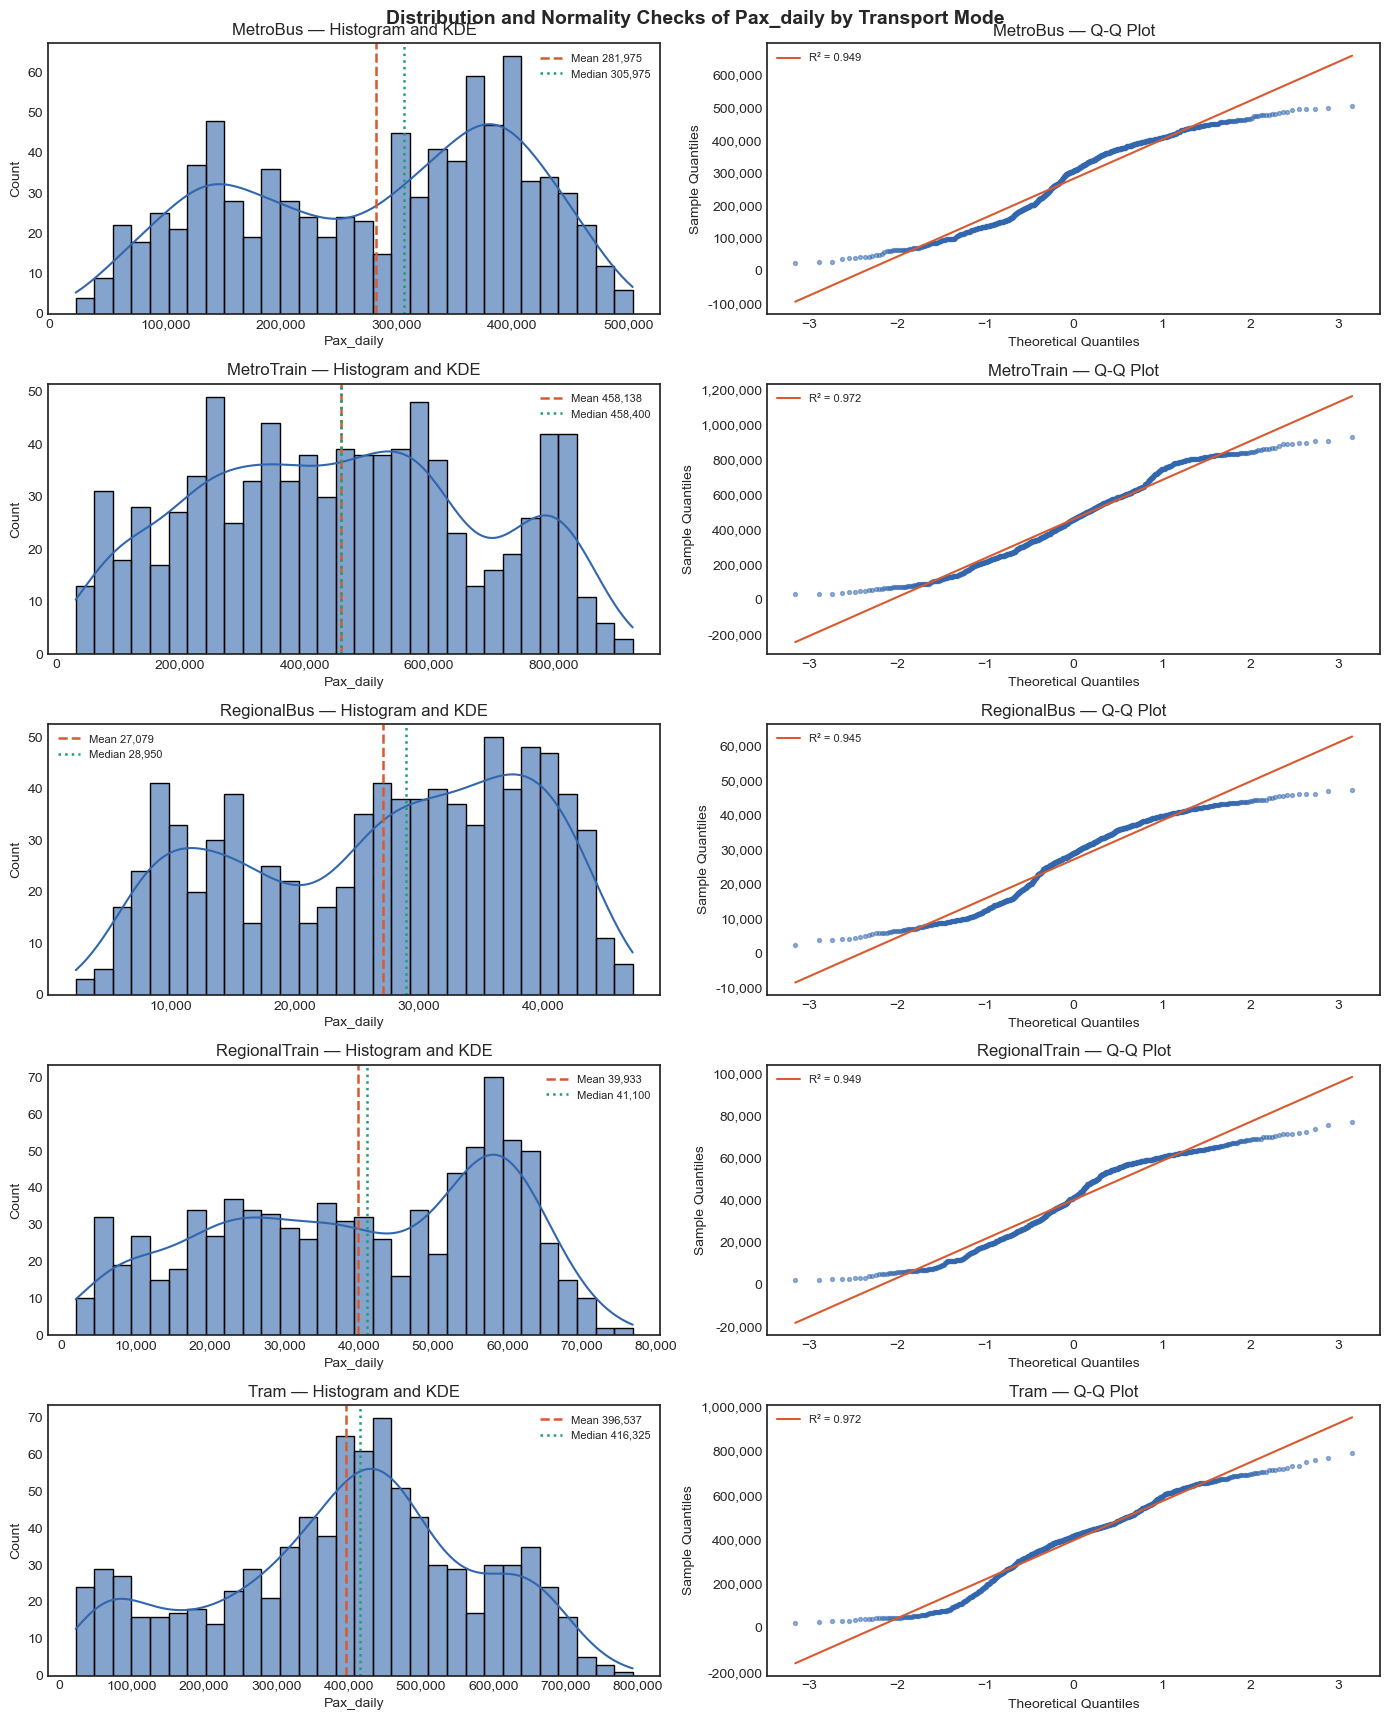

In [18]:
modes = df["Mode"].cat.categories.tolist()

fig, axes = plt.subplots(len(modes), 2, figsize=(14, len(modes) * 3.5))
fig.suptitle("Distribution and Normality Checks of Pax_daily by Transport Mode", fontsize=14, fontweight="bold")

for i, mode in enumerate(modes):
    vals = df[df["Mode"] == mode]["Pax_daily"].dropna()

    # LEFT: Histogram + KDE
    ax_hist = axes[i, 0]

    sns.histplot(
        vals,
        bins=30,
        kde=True,
        color="#3266ad",
        alpha=0.6,
        ax=ax_hist,
    )
    ax_hist.axvline(
        vals.mean(),
        color="#D85A30",
        linewidth=1.8,
        linestyle="--",
        label=f"Mean {vals.mean():,.0f}"
    )
    ax_hist.axvline(
        vals.median(),
        color="#1D9E75",
        linewidth=1.8,
        linestyle=":",
        label=f"Median {vals.median():,.0f}"
    )

    ax_hist.set_title(f"{mode} — Histogram and KDE")
    ax_hist.set_xlabel("Pax_daily")
    ax_hist.set_ylabel("Count")
    ax_hist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax_hist.legend(fontsize=8)

    # RIGHT: Q-Q plot
    ax_qq = axes[i, 1]

    (osm, osr), (slope, intercept, r) = stats.probplot(vals, dist="norm")

    ax_qq.scatter(osm, osr, s=8, alpha=0.5, color="#3266ad")
    ax_qq.plot(
        [osm[0], osm[-1]],
        [slope * osm[0] + intercept, slope * osm[-1] + intercept],
        color="#D85A30",
        linewidth=1.5,
        label=f"R² = {r**2:.3f}"
    )

    ax_qq.set_title(f"{mode} — Q-Q Plot")
    ax_qq.set_xlabel("Theoretical Quantiles")
    ax_qq.set_ylabel("Sample Quantiles")
    ax_qq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax_qq.legend(fontsize=8)

plt.tight_layout()
plt.show() 

# B2. Modelling

## B2.1. Segmented comparison across Period with 95% CIs
    

,Period,Mode,mean,std,count,se,ci95
0,Pre-2020,MetroBus,350686.34,118213.47,216,8043.41,15765.08
1,Pre-2020,MetroTrain,672133.56,202333.88,216,13767.08,26983.47
2,Pre-2020,RegionalBus,30255.79,11927.42,216,811.56,1590.65
3,Pre-2020,RegionalTrain,48380.56,14302.22,216,973.14,1907.36
4,Pre-2020,Tram,575107.18,125871.60,216,8564.48,16786.38
5,2020-2021,MetroBus,169377.68,98280.34,224,6566.63,12870.60
6,2020-2021,MetroTrain,242316.74,178972.31,224,11958.09,23437.86
7,2020-2021,RegionalBus,18754.69,10048.76,224,671.41,1315.97
8,2020-2021,RegionalTrain,19675.22,14142.67,224,944.95,1852.10
9,2020-2021,Tram,187077.23,135608.99,224,9060.76,17759.08


/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


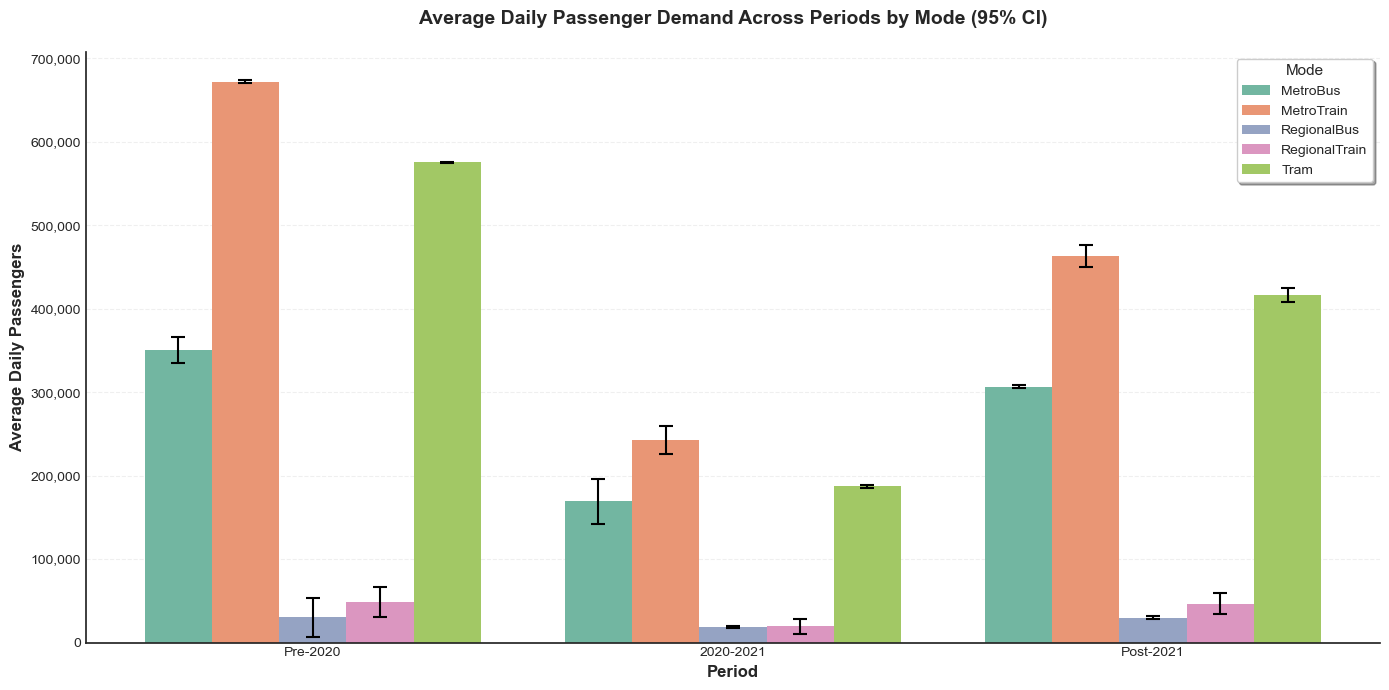

This segmented comparison shows how average patronage changes across the three major periods: Pre-2020, 2020–2021, and Post-2021. The confidence intervals help judge whether period-level differences are likely to be meaningful.


In [19]:
# Calculate segmented statistics
segmented_df = (
    df.groupby(["Period", "Mode"], observed=False)["Pax_daily"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

# Standard error and 95% CI
segmented_df["se"] = segmented_df["std"] / np.sqrt(segmented_df["count"])
segmented_df["ci95"] = 1.96 * segmented_df["se"]

# Keep order consistent
period_order = ["Pre-2020", "2020-2021", "Post-2021"]
mode_order = list(df["Mode"].cat.categories) if str(df["Mode"].dtype) == "category" else sorted(df["Mode"].unique())

segmented_df["Period"] = pd.Categorical(segmented_df["Period"], categories=period_order, ordered=True)
segmented_df["Mode"] = pd.Categorical(segmented_df["Mode"], categories=mode_order, ordered=True)
segmented_df = segmented_df.sort_values(["Period", "Mode"]).reset_index(drop=True)

# Show summary table
display(segmented_df.round(2))

# Plot segmented comparison with IMPROVED VISUALIZATION
fig, ax = plt.subplots(figsize=(14, 7))

# Create bar plot
sns.barplot(
    data=segmented_df,
    x="Period",
    y="mean",
    hue="Mode",
    order=period_order,
    hue_order=mode_order,
    palette="Set2",  # Better color palette
    errorbar=None,
    ax=ax
)

# Add correctly aligned 95% CI error bars
for i, patch in enumerate(ax.patches):
    row = segmented_df.iloc[i]
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    
    ax.errorbar(
        x=x,
        y=y,
        yerr=row["ci95"],
        fmt="none",
        ecolor="black",
        elinewidth=1.5,
        capsize=5,
        capthick=1.5
    )

# Formatting improvements
ax.set_title("Average Daily Passenger Demand Across Periods by Mode (95% CI)", 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("Period", fontsize=12, fontweight='bold')
ax.set_ylabel("Average Daily Passengers", fontsize=12, fontweight='bold')

# Format y-axis with thousands separator
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Improve legend
ax.legend(title="Mode", title_fontsize=11, fontsize=10, 
          frameon=True, shadow=True, loc='upper right')

# Grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Remove top and right spines
sns.despine()

plt.tight_layout()
plt.show()

# Plain-language interpretation
print(
    "This segmented comparison shows how average patronage changes across the three major periods: "
    "Pre-2020, 2020–2021, and Post-2021. The confidence intervals help judge whether period-level differences are likely to be meaningful."
)

## B2.2. Plain-language interpretation for modelling


In [20]:
print(
    "This segmented comparison shows how average patronage changes across the three major periods: "
    "Pre-2020, 2020–2021, and Post-2021. The confidence intervals help judge whether period-level differences are likely to be meaningful."
)

This segmented comparison shows how average patronage changes across the three major periods: Pre-2020, 2020–2021, and Post-2021. The confidence intervals help judge whether period-level differences are likely to be meaningful.


# B3. Probability statement


## B3.1. Estimate probability of exceeding a threshold on Normal Weekdays


In [21]:
prob_mode = "MetroTrain"
prob_day_type = "Normal Weekday"
threshold = 600000

prob_df = df[
    (df["Mode"] == prob_mode) &
    (df["Day_type"] == prob_day_type)
].copy()

prob_exceed = (prob_df["Pax_daily"] > threshold).mean()

print("Mode used:", prob_mode)
print("Day type used:", prob_day_type)
print("Operational threshold:", f"{threshold:,.0f}")
print("Estimated probability of exceeding threshold:", round(prob_exceed, 4))
print(f"That is about {prob_exceed * 100:.2f}% of observed records.")

Mode used: MetroTrain
Day type used: Normal Weekday
Operational threshold: 600,000
Estimated probability of exceeding threshold: 0.3996
That is about 39.96% of observed records.


## B3.2. Plain-language probability interpretation


In [22]:
print(
    f"For {prob_mode} on {prob_day_type}s, the estimated probability that Pax_daily exceeds "
    f"{threshold:,.0f} passengers is {prob_exceed * 100:.2f}%. "
    "This estimate is based on the historical sample and assumes future demand behaves similarly to the observed data."
)

For MetroTrain on Normal Weekdays, the estimated probability that Pax_daily exceeds 600,000 passengers is 39.96%. This estimate is based on the historical sample and assumes future demand behaves similarly to the observed data.


# Section C: 
## C1. Two-sample t-test for chosen_mode with Weekday vs Weekend comparison (per Mode)


In [23]:
chosen_mode = "MetroTrain"

mode_subset = df[
    (df["Mode"] == chosen_mode) &
    (df["WeekPart"].isin(["Weekday", "Weekend"]))
].copy()

weekday_group = mode_subset[mode_subset["WeekPart"] == "Weekday"]["Pax_daily"].dropna()
weekend_group = mode_subset[mode_subset["WeekPart"] == "Weekend"]["Pax_daily"].dropna()

# Welch's t-test
t_stat_1, p_value_1 = stats.ttest_ind(weekday_group, weekend_group, equal_var=False)

mean_weekday = weekday_group.mean()
mean_weekend = weekend_group.mean()
mean_diff = mean_weekday - mean_weekend

print("Test used: Welch's two-sample t-test")
print("Chosen mode:", chosen_mode)
print("Weekday mean:", round(mean_weekday, 2))
print("Weekend mean:", round(mean_weekend, 2))
print("Mean difference (Weekday - Weekend):", round(mean_diff, 2))
print("t-statistic:", round(t_stat_1, 4))
print("p-value:", p_value_1)

Test used: Welch's two-sample t-test
Chosen mode: MetroTrain
Weekday mean: 514258.88
Weekend mean: 260238.68
Mean difference (Weekday - Weekend): 254020.2
t-statistic: 23.0912
p-value: 1.305963755914408e-88


In [24]:
# Effect size and 95% CI

n1, n2 = len(weekday_group), len(weekend_group)
s1, s2 = weekday_group.std(ddof=1), weekend_group.std(ddof=1)

pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohen_d = (mean_weekday - mean_weekend) / pooled_sd

se_diff = np.sqrt((s1**2 / n1) + (s2**2 / n2))

df_welch = (
    ((s1**2 / n1 + s2**2 / n2) ** 2) /
    (((s1**2 / n1) ** 2) / (n1 - 1) + ((s2**2 / n2) ** 2) / (n2 - 1))
)

t_crit = stats.t.ppf(0.975, df_welch)

ci_lower = mean_diff - t_crit * se_diff
ci_upper = mean_diff + t_crit * se_diff

print("Cohen's d:", round(cohen_d, 4))
print("95% CI for mean difference:", (round(ci_lower, 2), round(ci_upper, 2)))

Cohen's d: 1.2751
95% CI for mean difference: (232422.66, 275617.73)


In [25]:
# Plain-language interpretation

def cohen_d_label(d):
    ad = abs(d)
    if ad < 0.2:
        return "negligible"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    else:
        return "large"

sig_text_1 = "statistically significant" if p_value_1 < 0.05 else "not statistically significant"

print(
    f"For {chosen_mode}, the two-sample t-test shows that the difference between weekday and weekend demand is {sig_text_1} "
    f"(p = {p_value_1:.4g}). The average weekday demand is {mean_diff:,.0f} passengers "
    f"{'higher' if mean_diff >= 0 else 'lower'} than weekend demand. "
    f"The effect size is {cohen_d_label(cohen_d)} (Cohen's d = {cohen_d:.2f}), "
    f"and the 95% confidence interval for the mean difference is [{ci_lower:,.0f}, {ci_upper:,.0f}] passengers."
)

For MetroTrain, the two-sample t-test shows that the difference between weekday and weekend demand is statistically significant (p = 1.306e-88). The average weekday demand is 254,020 passengers higher than weekend demand. The effect size is large (Cohen's d = 1.28), and the 95% confidence interval for the mean difference is [232,423, 275,618] passengers.


In [26]:
print(
    "Assumption note: The t-test was used after reviewing the distribution earlier with histograms, KDE plots, and Q-Q plots. "
    "With a large sample size, this comparison is treated as appropriate for estimating mean differences between weekday and weekend demand."
)

Assumption note: The t-test was used after reviewing the distribution earlier with histograms, KDE plots, and Q-Q plots. With a large sample size, this comparison is treated as appropriate for estimating mean differences between weekday and weekend demand.


## C2. One-way ANOVA with Differences across Modes on Normal Weekdays

In [27]:
normal_weekday_df = df[df["Day_type"] == "Normal Weekday"].copy()

mode_groups = []
mode_names = []

for mode in normal_weekday_df["Mode"].cat.categories:
    group = normal_weekday_df[normal_weekday_df["Mode"] == mode]["Pax_daily"].dropna()
    if len(group) > 1:
        mode_groups.append(group)
        mode_names.append(mode)

print("Modes included:", mode_names)
print("Group sizes:", [len(g) for g in mode_groups])

Modes included: ['MetroBus', 'MetroTrain', 'RegionalBus', 'RegionalTrain', 'Tram']
Group sizes: [453, 453, 453, 453, 453]


In [28]:
def shapiro_safe(series, max_n=500):
    sample = series.sample(min(len(series), max_n), random_state=42)
    return shapiro(sample)

In [29]:
# Assumption checks for ANOVA

shapiro_results = {}
for mode, group in zip(mode_names, mode_groups):
    shapiro_results[mode] = shapiro_safe(group).pvalue

levene_modes = levene(*mode_groups)

print("Shapiro p-values by mode:")
display(pd.Series(shapiro_results, name="Shapiro p-value"))

print("Levene p-value across modes:", levene_modes.pvalue)

print(
    "Assumption note: ANOVA assumes approximate normality within groups and similar variance across groups. "
    "These checks are used to support the choice of ANOVA."
)

Shapiro p-values by mode:


MetroBus         8.557069e-18
MetroTrain       2.203549e-11
RegionalBus      5.210686e-18
RegionalTrain    3.027246e-17
Tram             2.083222e-12
Name: Shapiro p-value, dtype: float64

Levene p-value across modes: 2.1400280055142258e-222
Assumption note: ANOVA assumes approximate normality within groups and similar variance across groups. These checks are used to support the choice of ANOVA.


In [30]:
# Run one-way ANOVA
f_stat_2, p_value_2 = stats.f_oneway(*mode_groups)

print("Test used: One-way ANOVA")
print("F-statistic:", round(f_stat_2, 4))
print("p-value:", p_value_2)

Test used: One-way ANOVA
F-statistic: 1291.7501
p-value: 0.0


In [31]:
# Effect size: eta squared

mode_weekday_means = normal_weekday_df.groupby("Mode", observed=False)["Pax_daily"].mean().round(2)
display(mode_weekday_means)

overall_mean = normal_weekday_df["Pax_daily"].mean()

ss_between = sum(len(group) * (group.mean() - overall_mean) ** 2 for group in mode_groups)
ss_total = ((normal_weekday_df["Pax_daily"] - overall_mean) ** 2).sum()

eta_squared = ss_between / ss_total

print("Eta squared:", round(eta_squared, 4))

Mode
MetroBus         344031.24
MetroTrain       541870.97
RegionalBus       34627.26
RegionalTrain     45946.03
Tram             440260.49
Name: Pax_daily, dtype: float64

Eta squared: 0.6957


In [32]:
sig_text_2 = "statistically significant" if p_value_2 < 0.05 else "not statistically significant"

# Fix p-value display
if p_value_2 < 0.001:
    p_text = "p < 0.001"
else:
    p_text = f"p = {p_value_2:.4f}"

print(
    f"The one-way ANOVA comparing transport modes on Normal Weekdays is {sig_text_2} "
    f"({p_text}). This indicates that average passenger demand differs across at least one transport mode. "
    f"The effect size (eta squared) is {eta_squared:.3f}, which shows how much of the variation in passenger demand is explained by Mode."
)

The one-way ANOVA comparing transport modes on Normal Weekdays is statistically significant (p < 0.001). This indicates that average passenger demand differs across at least one transport mode. The effect size (eta squared) is 0.696, which shows how much of the variation in passenger demand is explained by Mode.


## C3. Pre vs Post comparison (chosen Mode and Day_type)

In [33]:
chosen_mode = "MetroTrain"
chosen_day_type = "Normal Weekday"

pre_group = df[
    (df["Mode"] == chosen_mode) &
    (df["Day_type"] == chosen_day_type) &
    (df["Period"] == "Pre-2020")
]["Pax_daily"].dropna()

post_group = df[
    (df["Mode"] == chosen_mode) &
    (df["Day_type"] == chosen_day_type) &
    (df["Period"] == "Post-2021")
]["Pax_daily"].dropna()

print("Chosen mode:", chosen_mode)
print("Chosen day type:", chosen_day_type)
print("Pre-2020 n =", len(pre_group))
print("Post-2021 n =", len(post_group))

Chosen mode: MetroTrain
Chosen day type: Normal Weekday
Pre-2020 n = 115
Post-2021 n = 223


In [34]:
#Run Welch t-test
t_stat_3, p_value_3 = stats.ttest_ind(pre_group, post_group, equal_var=False)

mean_pre = pre_group.mean()
mean_post = post_group.mean()
mean_diff = mean_post - mean_pre

print("Test used: Welch's two-sample t-test")
print("Pre-2020 mean:", round(mean_pre, 2))
print("Post-2021 mean:", round(mean_post, 2))
print("Mean difference (Post - Pre):", round(mean_diff, 2))
print("t-statistic:", round(t_stat_3, 4))
print("p-value:", p_value_3)

Test used: Welch's two-sample t-test
Pre-2020 mean: 804790.0
Post-2021 mean: 539645.74
Mean difference (Post - Pre): -265144.26
t-statistic: 37.6731
p-value: 3.5021396319690395e-122


In [35]:
#. Effect size + 95% CI
n1, n2 = len(pre_group), len(post_group)
s1, s2 = pre_group.std(ddof=1), post_group.std(ddof=1)

# Cohen's d
pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohen_d_3 = (mean_post - mean_pre) / pooled_sd

# CI
se_diff = np.sqrt((s1**2 / n1) + (s2**2 / n2))

df_welch = (
    ((s1**2 / n1 + s2**2 / n2) ** 2) /
    (((s1**2 / n1) ** 2) / (n1 - 1) + ((s2**2 / n2) ** 2) / (n2 - 1))
)

t_crit = stats.t.ppf(0.975, df_welch)

ci_lower = mean_diff - t_crit * se_diff
ci_upper = mean_diff + t_crit * se_diff

print("Cohen's d:", round(cohen_d_3, 4))
print("95% CI:", (round(ci_lower, 2), round(ci_upper, 2)))

Cohen's d: -3.6585
95% CI: (-278988.79, -251299.73)


In [36]:
# interpretation
def cohen_d_label(d):
    ad = abs(d)
    if ad < 0.2:
        return "negligible"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    else:
        return "large"

# p-value formatting
if p_value_3 < 0.001:
    p_text = "p < 0.001"
else:
    p_text = f"p = {p_value_3:.4f}"

sig_text_3 = "statistically significant" if p_value_3 < 0.05 else "not statistically significant"

print(
    f"For {chosen_mode} on {chosen_day_type}s, the difference between Pre-2020 and Post-2021 demand is {sig_text_3} "
    f"({p_text}). The average demand in the post period is {abs(mean_diff):,.0f} passengers "
    f"{'higher' if mean_diff > 0 else 'lower'} than the pre period. "
    f"The effect size is {cohen_d_label(cohen_d_3)} (Cohen's d = {cohen_d_3:.2f}), "
    f"with a 95% confidence interval of [{ci_lower:,.0f}, {ci_upper:,.0f}] passengers."
)

For MetroTrain on Normal Weekdays, the difference between Pre-2020 and Post-2021 demand is statistically significant (p < 0.001). The average demand in the post period is 265,144 passengers lower than the pre period. The effect size is large (Cohen's d = -3.66), with a 95% confidence interval of [-278,989, -251,300] passengers.


In [37]:
#Assumption note
print(
    "Assumption note: The t-test was applied based on earlier distribution checks (histograms, KDE, Q-Q plots). "
    "With large sample sizes, the test is considered appropriate for comparing mean demand between periods."
)

Assumption note: The t-test was applied based on earlier distribution checks (histograms, KDE, Q-Q plots). With large sample sizes, the test is considered appropriate for comparing mean demand between periods.


# Section D:

## D1. Save cleaned data and summary outputs for Final Report

In [39]:
CLEANED_FILE = "../output/cleaned_patronage_data.csv"
df.to_csv(CLEANED_FILE, index=False)

desc_mode.to_csv("../output/summary_mode.csv")
desc_day_type.to_csv("../output/summary_day_type.csv")
desc_day_of_week.to_csv("../output/summary_day_of_week.csv")
desc_period.to_csv("../output/summary_period.csv")
ci_data.to_csv("../output/ci_summary_mode_daytype.csv", index=False)
segmented_df.to_csv("../output/segmented_period_mode_summary.csv", index=False)

print("Saved:", CLEANED_FILE)
print("Saved additional summary CSV files.")

Saved: ../output/cleaned_patronage_data.csv
Saved additional summary CSV files.
